# The reader arm — a reader ignores how a brief is *written*, not what it *says*

**What this is.** The diagnostic walk-through for probe `P-R` of
`reports/wf_spec_quality_plan.md`: the same 14 brief variants the matcher arm scored, put in front of
an **LLM screener** instead of a BM25 matcher. It exists to answer one question with a build decision
attached — does a spec linter need **two** critics, as `academic_agent`'s D43 assumes, or one?

**Total spend $1.40 of a $10 ceiling**, and stage 2 was deliberately not bought (see §5).

**Three things to hold onto while reading.**

1. **A null result is unreadable without a floor.** "The reader did not notice the damage" and "our
   instrument cannot see anything" produce identical numbers. So every table below carries the
   **shuffled-brief derangement** — every collection scored against a different collection's brief.
   Read it first, in §1. If the derangement also sat at zero, nothing else here would mean anything.
2. **0.500 AUC is a coin flip, and a gap under 0.03 is not a result** (`CONTEXT.md` §5: seed-to-seed
   noise is ~0.010). Almost every degradation below is inside that band — and *that is the finding*,
   not a weakness of it.
3. **The prediction was backwards.** The plan expected contradiction and fluff to be *worse* for a
   reader than for a matcher. They are worse for the matcher and free for the reader.

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

sys.path.insert(0, "../../scripts")

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 220)

REPORTS = Path("../../reports")
FLOOR = 0.03   # CONTEXT.md §5 - gaps under this are not established

# --- chart style -------------------------------------------------------------
SURF = {"live": "#eb6834", "benchset": "#2a78d6"}
INK, INK2, GRID = "#0b0b0b", "#52514e", "#dcdbd6"
SEQ = LinearSegmentedColormap.from_list("seq", ["#cde2fb", "#6da7ec", "#2a78d6", "#184f95", "#0d366b"])
DIV = LinearSegmentedColormap.from_list("div", ["#0d366b", "#2a78d6", "#f0efec", "#e34948", "#8f1f1f"])

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110, "font.size": 9,
    "axes.edgecolor": GRID, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.titlesize": 10, "axes.titleweight": "bold", "axes.grid": True,
    "grid.color": GRID, "grid.linewidth": 0.6, "xtick.color": INK2, "ytick.color": INK2,
    "axes.spines.top": False, "axes.spines.right": False, "legend.frameon": False,
})

R = pd.read_csv(REPORTS / "wf_spec_quality_reader_stage1.csv")
ORDER = [v for v in ["full", "keyword_flood", "fluff_replace", "vague_objective",
                     "conflicting", "only_name", "shuffled"] if v in set(R.variant)]
print(f"{R.use_case.nunique()} collections x {R.variant.nunique()} cells")
print("cells:", ORDER)

8 collections x 8 cells
cells: ['full', 'keyword_flood', 'fluff_replace', 'vague_objective', 'conflicting', 'only_name', 'shuffled']


## 1. The floor first — the instrument is not blind, and it is not subtle

The **derangement**: no collection keeps its own brief; each is scored against another use case's.
`CONTEXT.md` L258–260 requires this control of anything claiming to read a brief. It is the
calibration that makes every null below interpretable.

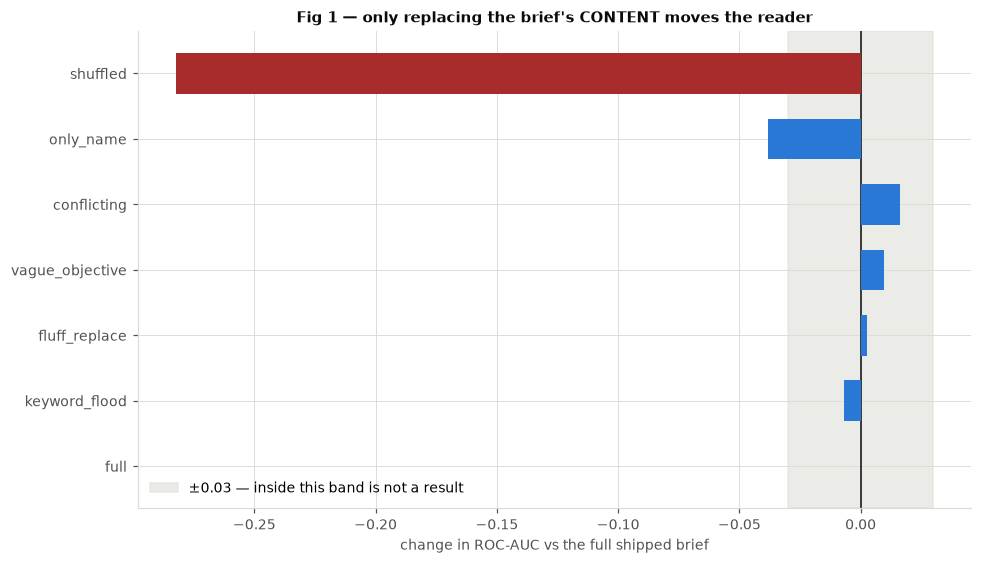

shuffled:  d AUC -0.282   d F2@own -0.297   d fraction-read -0.158
           worse than the 0.03 floor on 7 of 8 collections

spread across the real degradations (excluding full/shuffled): 0.054


In [2]:
piv = R.pivot(index="use_case", columns="variant", values="reader_d_auc")[ORDER]
mean_d = piv.mean()

fig, ax = plt.subplots(figsize=(9, 5.2))
cols = [DIV(0.92) if v == "shuffled" else SURF["benchset"] for v in ORDER]
ax.barh(np.arange(len(ORDER)), mean_d.values, color=cols, height=0.62, zorder=3)
ax.axvspan(-FLOOR, FLOOR, color=GRID, alpha=0.55, zorder=1,
           label=f"±{FLOOR} — inside this band is not a result")
ax.axvline(0, color=INK, lw=1, zorder=2)
ax.set_yticks(np.arange(len(ORDER))); ax.set_yticklabels(ORDER)
ax.set(xlabel="change in ROC-AUC vs the full shipped brief",
       title="Fig 1 — only replacing the brief's CONTENT moves the reader")
ax.legend(loc="lower left")
plt.tight_layout(); plt.show()

sh = R[R.variant == "shuffled"]
print(f"shuffled:  d AUC {sh.reader_d_auc.mean():+.3f}   d F2@own {sh.reader_d_f2_own.mean():+.3f}"
      f"   d fraction-read {sh.reader_d_screened_own.mean():+.3f}")
print(f"           worse than the {FLOOR} floor on "
      f"{int((piv['shuffled'] < -FLOOR).sum())} of {len(piv)} collections")
print(f"\nspread across the real degradations (excluding full/shuffled): "
      f"{mean_d.drop(['full', 'shuffled']).max() - mean_d.drop(['full', 'shuffled']).min():.3f}")

**Hard finding — the reader is genuinely reading.** Hand each collection somebody else's brief and it
loses **0.282 AUC**, its F2 at its own operating point falls **0.297**, and it reads **15.8 percentage
points less** of the corpus — worse than the noise floor on 7 of 8 collections. This reproduces the
published set-A floor (0.777 → 0.498) and cost **$0.00**, because that cell was already cached.

*ELI18: we gave the model instructions for a completely different research question, and its ability
to pick out relevant papers collapsed. That is the proof the test works. So when the damaged-but-
on-topic briefs below change nothing, that is a fact about the damage, not a broken measurement.*

⚠️ **The one exception is `moran_2021`, where the derangement scores +0.068** — because its own-brief
AUC is **0.455, below a coin flip**. A brief cannot be made much worse than actively wrong.
`CONTEXT.md` already records `moran_2021` as a collection whose inclusion rule is learnable in
representation space and *not statable as a rule*.

## 2. The degradations, against the matcher that saw the same 14 texts

H1 and H3 are comparisons *between arms*, so they need a matcher number to subtract. There are two,
at different label counts, and **both are shown because neither is a clean match** to a zero-shot
reader:

- **fitted** (60 labels, full lexical block) — the comparator the plan named.
- **unfitted worst** (0 labels, one feature) — label-matched to the reader, and taken as the *most
  negative* of the three single features, because each variant damages a different one. Reading a
  fixed column would report a confident 0.000 for variants it does not measure.

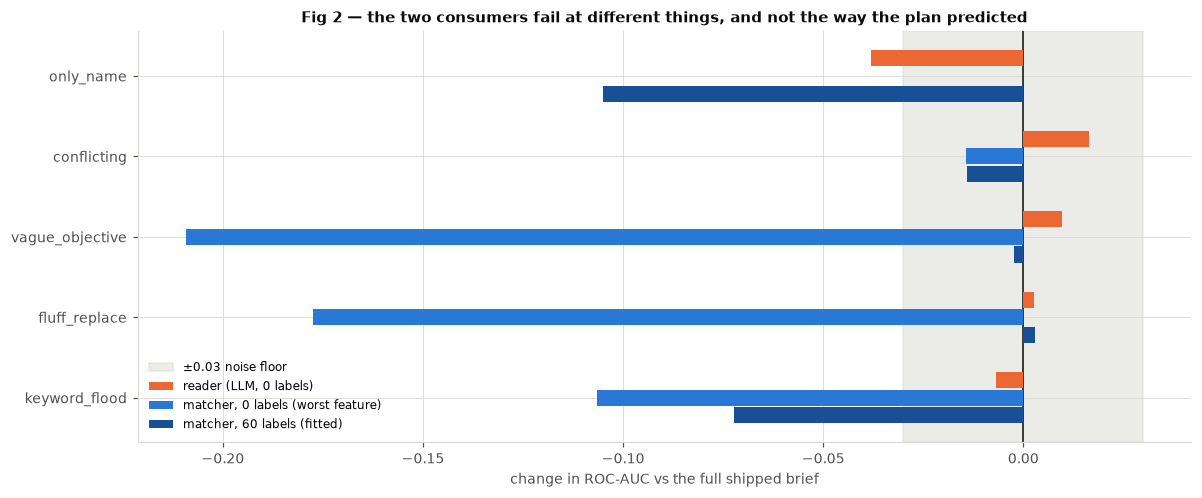

,reader,matcher_fitted,matcher_unfitted,reader_worse_n,reader_better_n
variant,,,,,
full,0.000,0.000,0.000,0,0
keyword_flood,-0.007,-0.072,-0.106,0,0
fluff_replace,0.003,0.003,-0.177,2,1
vague_objective,0.010,-0.002,-0.209,2,2
conflicting,0.016,-0.014,-0.014,1,2
only_name,-0.038,-0.105,NaN,5,1
shuffled,-0.282,NaN,NaN,7,1


In [3]:
agg = R.groupby("variant").agg(
    reader=("reader_d_auc", "mean"),
    matcher_fitted=("matcher_fitted_d", "mean"),
    matcher_unfitted=("matcher_unfitted_worst_d", "mean"),
).reindex(ORDER)
agg["reader_worse_n"] = piv.lt(-FLOOR).sum()
agg["reader_better_n"] = piv.gt(FLOOR).sum()

show = agg.drop(index=["full"]).drop(index=["shuffled"], errors="ignore")
y = np.arange(len(show))
fig, ax = plt.subplots(figsize=(11, 4.6))
ax.barh(y + 0.22, show.reader, height=0.2, color=SURF["live"], label="reader (LLM, 0 labels)", zorder=3)
ax.barh(y, show.matcher_unfitted, height=0.2, color=SURF["benchset"], label="matcher, 0 labels (worst feature)", zorder=3)
ax.barh(y - 0.22, show.matcher_fitted, height=0.2, color="#184f95", label="matcher, 60 labels (fitted)", zorder=3)
ax.axvspan(-FLOOR, FLOOR, color=GRID, alpha=0.55, zorder=1, label=f"±{FLOOR} noise floor")
ax.axvline(0, color=INK, lw=1, zorder=2)
ax.set_yticks(y); ax.set_yticklabels(show.index)
ax.set(xlabel="change in ROC-AUC vs the full shipped brief",
       title="Fig 2 — the two consumers fail at different things, and not the way the plan predicted")
ax.legend(loc="lower left", fontsize=8)
plt.tight_layout(); plt.show()
display(agg.round(3))

**Hard finding — every degradation costs the reader less than the noise floor, and three of them are
*positive*.** The whole spread across the four pre-registered variants is **0.023**.

**Hard finding — the matcher's cold-start arm is devastated by exactly the variants the reader
shrugs off.** `vague_objective` costs the matcher **−0.209** and the reader **+0.010**;
`fluff_replace` costs the matcher **−0.177** and the reader **+0.003**. The plan predicted the
opposite, reasoning that "a reader consumes instructions, and there are none left". In fact the
instruction-consumer is the *matcher*: its cold-start features read the brief's prose directly and
have nothing to fall back on, while the reader still has the topic.

**Judgement call — the per-collection scatter says noise, not effect.** `conflicting` is worse than
the floor on 1 collection and *better* by more than the floor on 2; `vague_objective` is 2 and 2. A
real effect does not scatter symmetrically.

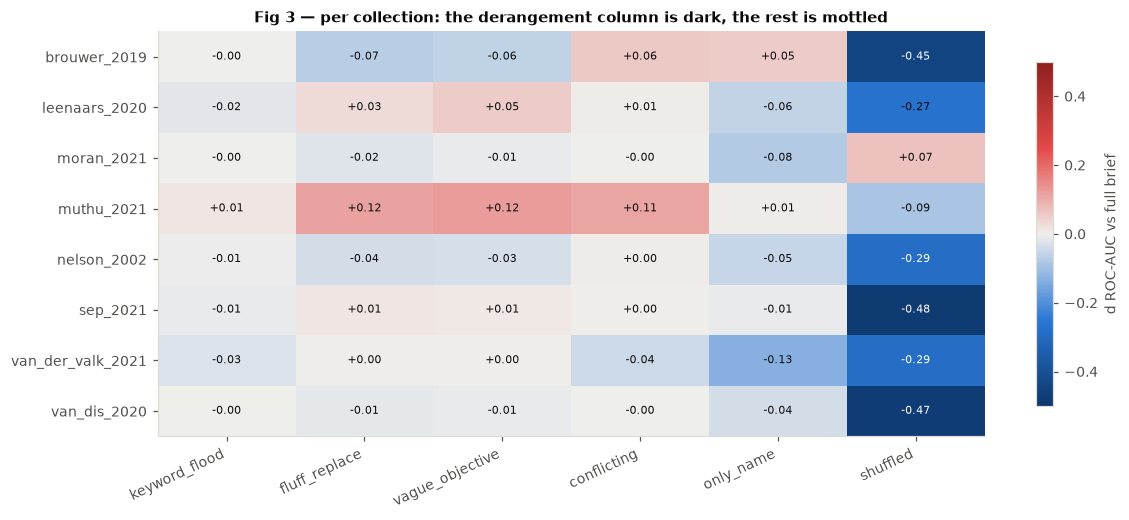

collections where the degradation HELPED by more than the floor:
  keyword_flood    0 -> []
  fluff_replace    1 -> ['muthu_2021']
  vague_objective  2 -> ['leenaars_2020', 'muthu_2021']
  conflicting      2 -> ['brouwer_2019', 'muthu_2021']
  only_name        1 -> ['brouwer_2019']


In [4]:
show2 = piv.drop(columns=["full"])
fig, ax = plt.subplots(figsize=(11, 4.8))
im = ax.imshow(show2.values, cmap=DIV, vmin=-0.5, vmax=0.5, aspect="auto")
ax.set_xticks(range(len(show2.columns))); ax.set_xticklabels(show2.columns, rotation=25, ha="right")
ax.set_yticks(range(len(show2.index))); ax.set_yticklabels(show2.index)
for i in range(show2.shape[0]):
    for j in range(show2.shape[1]):
        v = show2.values[i, j]
        ax.text(j, i, f"{v:+.2f}", ha="center", va="center", fontsize=7,
                color="white" if abs(v) > 0.28 else INK)
ax.grid(False)
ax.set(title="Fig 3 — per collection: the derangement column is dark, the rest is mottled")
fig.colorbar(im, ax=ax, label="d ROC-AUC vs full brief", shrink=0.85)
plt.tight_layout(); plt.show()

print("collections where the degradation HELPED by more than the floor:")
for v in show2.columns:
    if v == "shuffled":
        continue
    w = sorted(show2.index[show2[v] > FLOOR])
    print(f"  {v:16s} {len(w)} -> {w}")

**Hard finding — `muthu_2021` is helped by every single degradation** (+0.112 `conflicting`, +0.117
`fluff_replace`, +0.125 `vague_objective`). 🟡 **Judgement call:** its shipped brief appears to
*mislead* this reader, and damaging it removes the misleading part. n=1, exploratory — but it is
exactly the failure the foreign-brief probe was built to detect, and worth cross-checking against
that probe's margin for `muthu_2021`.

## 3. The diagnostic that explains the null — how little does the reader actually need?

Every variant so far leaves `use_case_name` intact — `variant()` never clears it. So a reader that
extracts the topic from the 2–4 word name would be indifferent to everything done to the prose and the
term lists, which is exactly the pattern above.

`only_name` tests that directly: the name and nothing else. It is the worst variant the matcher
measured (**−0.105** on set A) and it is what `embedding_utils.get_use_case_text` falls back to
today, so it is the floor the `scripts/*.py` path actually ships.

In [5]:
if "only_name" in set(R.variant):
    on = R[R.variant == "only_name"]
    m = agg.loc["only_name"]
    print(f"only_name:  reader d AUC {m.reader:+.3f}    matcher fitted {m.matcher_fitted:+.3f}"
          f"    matcher unfitted worst {m.matcher_unfitted:+.3f}")
    print(f"            worse than the {FLOOR} floor on {int(m.reader_worse_n)} of {len(piv)}"
          f", better on {int(m.reader_better_n)} of {len(piv)}")
    print(f"            vs the derangement's {agg.loc['shuffled', 'reader']:+.3f}")
    print(f"\nd F2@own {on.reader_d_f2_own.mean():+.3f}   "
          f"d fraction-read {on.reader_d_screened_own.mean():+.3f}")
    display(piv[["only_name", "shuffled"]].round(3))
else:
    print("only_name cell not present in this stage-1 run")

only_name:  reader d AUC -0.038    matcher fitted -0.105    matcher unfitted worst +nan
            worse than the 0.03 floor on 5 of 8, better on 1 of 8
            vs the derangement's -0.282

d F2@own -0.018   d fraction-read +0.039


variant,only_name,shuffled
use_case,,
brouwer_2019,0.054,-0.445
leenaars_2020,-0.056,-0.271
moran_2021,-0.075,0.068
muthu_2021,0.006,-0.086
nelson_2002,-0.055,-0.286
sep_2021,-0.011,-0.477
van_der_valk_2021,-0.132,-0.288
van_dis_2020,-0.037,-0.473


**Hard finding — it lands between the two anchors, at −0.038, and that is informative.**
The derangement (wrong topic) costs −0.282; the full brief is the 0.000 reference. `only_name` clears
the 0.03 floor and is worse than the floor on **5 of 8** collections — so the brief's prose is
genuinely worth something to a reader, about **0.04** — but it is nowhere near a wrong brief.

**So the mechanism behind §2's null is redundancy, not indifference.** Each of the four degradations
corrupts one part of the brief and the remaining fields still carry the topic. That changes how §2
must be read: not *"spec quality does not matter to a reader"* but *"no single field is load-bearing
for a reader, because the same information sits in several of them."* A degradation corrupting **all**
fields at once has not been measured; `only_name` is the closest thing to it here.

*ELI18: the brief is an instruction sheet whose sections all describe the same topic in different
words. Tear off everything but the title and the model gets slightly worse (0.04). Scribble over any
one section and it does not get worse at all, because the other sections still say what the topic is.
Swap the sheet for a different project's and it falls apart (0.28).*

⚠️ Note `only_name` **raises** fraction-read by 3.9 points while lowering F2@own by 0.018 — given only
a topic label the reader flags *more* papers, less precisely. That is a failure a ranker cannot
exhibit at all, and it is the one surviving argument for a reader-side critic (see §4).


## 3b. The prose contradiction — the one thing only a reader shows

§2's `conflicting` moves `terms_exclude` into `terms_must_include`: a contradiction between two **list**
fields, and it cost the reader nothing (+0.016). But S-AL's measured result was about a contradiction in
**prose** — a policy sentence naming as positive the category its own labels rejected. Those are not the
same manipulation, so `conflicting` never tested it.

`conflicting_prose` does: a plausible policy sentence appended to the objective asserting the spec's own
**excluded** categories are wanted, built from `terms_exclude` and leaving that list intact — so the spec
contradicts its sibling field *and* its own labels.

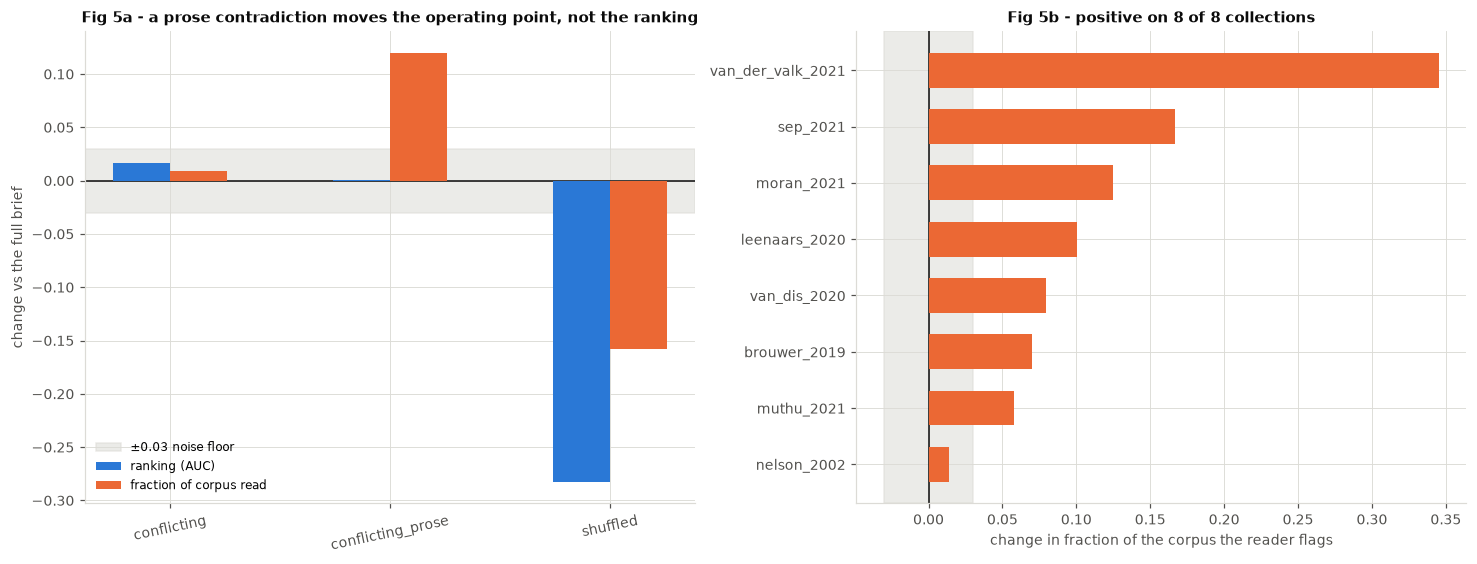

conflicting_prose  ranking (AUC)            mean +0.001   positive on 3/8
conflicting_prose  fraction of corpus read  mean +0.120   positive on 8/8
conflicting_prose  recall                   mean +0.112   positive on 5/8
conflicting_prose  F2@own                   mean -0.002   positive on 4/8

AUC worse than the floor on 3 collections, BETTER by more than the floor on 3 - symmetric, i.e. noise.


In [6]:
V = ["conflicting", "conflicting_prose", "shuffled"]
metrics = [("reader_d_auc", "ranking (AUC)"), ("reader_d_screened_own", "fraction of corpus read"),
           ("reader_d_recall_own", "recall"), ("reader_d_f2_own", "F2@own")]

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2))
ax = axes[0]
w = 0.26
for i, (col, lab) in enumerate(metrics[:2]):
    means = [R[R.variant == v][col].mean() for v in V]
    ax.bar(np.arange(len(V)) + (i - 0.5) * w, means, width=w,
           color=[SURF["benchset"], SURF["live"]][i], label=lab, zorder=3)
ax.axhspan(-FLOOR, FLOOR, color=GRID, alpha=0.55, zorder=1, label=f"±{FLOOR} noise floor")
ax.axhline(0, color=INK, lw=1, zorder=2)
ax.set_xticks(np.arange(len(V))); ax.set_xticklabels(V, rotation=12)
ax.set(ylabel="change vs the full brief",
       title="Fig 5a - a prose contradiction moves the operating point, not the ranking")
ax.legend(loc="lower left", fontsize=8)

ax = axes[1]
pr = R[R.variant == "conflicting_prose"].set_index("use_case").sort_values("reader_d_screened_own")
ax.barh(np.arange(len(pr)), pr.reader_d_screened_own, color=SURF["live"], zorder=3, height=0.62)
ax.axvspan(-FLOOR, FLOOR, color=GRID, alpha=0.55, zorder=1)
ax.axvline(0, color=INK, lw=1, zorder=2)
ax.set_yticks(np.arange(len(pr))); ax.set_yticklabels(pr.index)
ax.set(xlabel="change in fraction of the corpus the reader flags",
       title=f"Fig 5b - positive on {int((pr.reader_d_screened_own > 0).sum())} of {len(pr)} collections")
plt.tight_layout(); plt.show()

for col, lab in metrics:
    m = R[R.variant == "conflicting_prose"][col]
    print(f"conflicting_prose  {lab:24s} mean {m.mean():+.3f}   positive on {int((m > 0).sum())}/{len(m)}")
print(f"\nAUC worse than the floor on {int((pr.reader_d_auc < -FLOOR).sum())} collections, "
      f"BETTER by more than the floor on {int((pr.reader_d_auc > FLOOR).sum())} - symmetric, i.e. noise.")

**Hard finding — ranking untouched, operating point moved on 8 of 8.** AUC is **+0.001** with a
symmetric scatter (3 collections worse than the floor, 3 better) — the signature of noise. But
fraction-read is **positive on every single collection** (+1.4 to +34.5pp, mean **+0.120**) and recall
is up on all eight. The model obeys the contradicting sentence: it includes the categories the spec
said to exclude, so it flags more papers, in the same order.

**Hard finding — a *fitted* matcher cannot see this at all.** 0 of 8, 0 of 7 and 0 of 6 collections
affected after 60 labels across set A, set B and TIRI's own six. It appears only in the matcher's
zero-label prose feature (−0.018 / −0.042 / −0.037). **So this is the one defect in the whole ablation
that a reader detects and a fitted matcher does not** — a real, narrow, now-priced job for a second
critic, and the reason §4's "one critic" conclusion is qualified rather than absolute.

⚠️ **S-AL's number is not reproduced.** S-AL measured −0.056 AUC; this measures +0.001 AUC plus a
12-point read shift. The honest reading is *"the effect is real and AUC was the wrong instrument"* —
neither confirmation nor refutation. One model family, one corpus, and a manipulation built from the
spec's own exclude list rather than a hand-written policy.

⚠️ **F2 being a wash is a prevalence artefact.** −0.003 at this subsample's 13.6% positive rate,
because the extra recall roughly pays for the extra reading. At production prevalence (~2%) reading
12pp more of a corpus for recall you did not need would not be a wash — but `CONTEXT.md` §4 forbids
carrying a threshold across regimes, so that is an expectation, not a measurement.

🟢 **It is now a linter check.** `exclude_asserted_in_prose` in `scripts/spec_linter.py`, at **0/34
false positives** on real specs and firing on **8/8** constructed cases.

## 4. The three pre-registered bars, and what they change

| | bar | result |
|---|---|---|
| **H1** | `conflicting` costs the reader ≥0.03 **more** than the matcher, on ≥5 of 8 | **FAIL** — reader **+0.016** vs matcher −0.014; clears on 1 of 8 |
| **H2** | `fluff_replace` **and** `vague_objective` cost the reader ≥0.03 | **FAIL** both — **+0.003** and **+0.010** |
| **H3** | `keyword_flood` costs the reader **less** than the matcher | **PASS** — **−0.007** vs **−0.072** |

**What this changes: D43's spec linter needs one critic, not two — and it is the matcher.**

| failure mode | matcher notices | reader notices |
|---|---|---|
| generic-keyword padding | **yes** (−0.072 set A, −0.031 set B) | no (−0.007) |
| fluff / vague prose | **yes, catastrophically, at 0 labels** (−0.177 / −0.209) | no (+0.003 / +0.010) |
| self-contradicting term lists | barely (−0.014 / −0.009) | no (+0.016) |
| wrong topic entirely | **yes** | **yes, decisively** (−0.282) |

Every row the reader notices, the matcher notices too. **No failure mode in this ablation is visible
only to the reader**, so a two-critic linter buys nothing over a one-critic linter.

⚠️ **What the reader arm does uniquely contribute is the operating point**, which a ranker cannot
produce at all: the derangement drops fraction-read by 15.8 points and F2@own by 0.297. A check that
wants to say *"this brief will make the model stop flagging papers"* needs a reader. One that wants to
say *"this brief is badly written"* does not.

🔴 **What this does NOT do is refute S-AL.** S-AL's 0.828 → 0.772 came from contradicting the brief
**in prose** — a policy sentence naming as positive the category its own labels rejected. This
variant contradicts it **in the term lists**. If the reader largely ignores term-list fields — which
`keyword_flood` (−0.007) and `CONTEXT.md` §6's separate rejection of "LLM-written `terms_*` for an
LLM reader" both support — then these are not the same experiment. **S-AL is un-addressed here, not
refuted**, and testing it needs a prose-contradiction variant this ablation does not contain.

## 5. Read this before quoting any number above

1. **The pre-registered stop rule fired and was honoured.** The plan said: *stop if all four variants
   sit inside 0.03 of each other — that is itself the answer, and stage 2 adds nothing.* The spread is
   0.023, so **stage 2 on set B was not bought**. That saves $3.30 and, more valuably, leaves the
   repo's last clean surface unspent. Overriding a stop rule because the null turned out interesting
   is the behaviour the rule exists to prevent.
2. **One model family, unreplicated.** `gemma-4-31b-it` only — the *weakest* of the four on set A,
   which makes a null conservative rather than flattering, but a stronger reader could be more
   sensitive to spec form, not less.
3. **Set A only, and set A is burned** (five selection passes). The null is the finding *on set A*.
4. **Tie fraction 0.94–1.00.** Verbalised 0–100 scores are extremely lumpy, so AUC is a coarse
   instrument here. Mitigated, not eliminated, by the 0.282 floor.
5. **Small per collection:** ~250 rows each, 271 positives over 8 collections, `sep_2021` at 54 rows.
   Win counts sit beside every mean for that reason, and stage 1 was pre-registered as
   estimates-only.
6. **Parse rate 100.0% on every cell**, and the brief-hash instrument check asserted every variant
   renders a distinct text on every collection before any money was spent.
7. **4 of 14 variants bought**, plus `only_name` as a diagnostic. The other nine are out of budget
   (~$6.6 more on set B) and deliberately unbought.